In [42]:
import os
from huggingface_hub import snapshot_download
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

In [67]:
# input data
hepg2_raw_adata_path = "/data/storage/Replogle/raw_data/GSE264667_hepg2_raw_singlecell_01.h5ad"
preprocessed_adata_path = "/data/storage/Replogle/processed_data/replogle.h5ad"
x_atlas_sgrna_path = "/data/storage/X-Atlas/HCT116/h5ad/HCT116_filtered_guide_calls_per_cell.csv"

preprocessed_sub_ds_ntc_ko_ntc_adata_path = "/data/storage/Replogle/processed_data/replogle_hepg2_sub_ko_ntc.h5ad"
raw_sub_ds_ntc_ko_ntc_adata_path = "/data/storage/Replogle/raw_data/replogle_hepg2_sub_ko_ntc.h5ad"

# intermediate data
preprocessed_hepg2_path = "/data/storage/Replogle/processed_data/replogle_hepg2.h5ad"
processed_sub_hepg2_path = "/data/storage/Replogle/processed_data/replogle_hepg2_sub.h5ad"

# output data
raw_sub_hepg2_path = "/data/storage/Replogle/raw_data/GSE264667_hepg2_raw_singlecell_01_sub.h5ad"
preprocessed_hepg2_sub_ds_ntc_path = "/data/storage/Replogle/processed_data/replogle_hepg2_sub.h5ad"

In [68]:
## Read adata
# hepg2_raw_adata = sc.read_h5ad(hepg2_raw_adata_path)
raw_sub_ds_ntc_adata = sc.read_h5ad(raw_sub_hepg2_path)

# preprocessed_adata = sc.read_h5ad(preprocessed_adata_path)
# preprocessed_hepg2_adata = sc.read_h5ad(preprocessed_hepg2_path)
# preprocessed_sub_ds_ntc_adata = sc.read_h5ad(preprocessed_hepg2_sub_ds_ntc_path)
# preprocessed_sub_ds_ntc_ko_ntc_adata = sc.read_h5ad(preprocessed_sub_ds_ntc_ko_ntc_adata_path)
raw_sub_ds_ntc_ko_ntc_adata = sc.read_h5ad(raw_sub_ds_ntc_ko_ntc_adata_path)

In [21]:
# genes_list=["MYC", "MYBL2", "CDK1", "TFAM", "MTOR",
#             "STAT5B", "BAP1", "BRCA1", "SETD1A", "NELFA",
#            "HAMP", "S100A1", "LRP5", "MAP2K7", "RHOQ"]
genes_list=["CDC42", "CDK1", "LRP5", "MAP2K7", "MYBL2", "MYC", "TFAM"]
control=["non-targeting"]

# Calculate KD percentage

In [10]:
raw_token_map = dict(raw_sub_ds_ntc_adata.obs[["gene", "gene_id"]].drop_duplicates().values)

In [4]:
def knockdown(target_gene, adata, data, obs_col="gene_target", ntc="Non-Targeting"):
    if data =="raw":
        ensg_id = raw_token_map[target_gene]
        idx = adata.var_names.get_loc(ensg_id)
    else:
        idx = adata.var_names.get_loc(target_gene)

    
    gene_adata = adata[adata.obs[obs_col]==target_gene].copy()
    ntc_adata = adata[adata.obs[obs_col]==ntc].copy()

    gene_expression = gene_adata.X[:, idx]
    ntc_gene_expression = ntc_adata.X[:, idx]

    

    # pert = adata.obs[obs_col] == target_gene
    # ctrl = adata.obs[obs_col] == ntc
    # print(idx)
    # print(pert)

    pert_expr = gene_expression.mean()
    ctrl_expr = ntc_gene_expression.mean()

    log2FC = np.log2((pert_expr + 1e-6) / (ctrl_expr + 1e-6))
    knockdown = 1 - pert_expr / ctrl_expr
    
    print(target_gene)
    print(f"Mean target expression in perturbed: {pert_expr}")
    print(f"Mean target expression in control: {ctrl_expr}")
    print(f"log2FC: {log2FC}")
    print(f"knockdown: {knockdown}")
    print("\n")
    

    return {
        "gene": target_gene,
        "log2FC": log2FC,
        "knockdown": knockdown
    }

In [12]:
results = []
for gene in genes_list[:-1]:
    result_dict = knockdown(gene, preprocessed_sub_ds_ntc_adata, "preprocessed", obs_col="gene", ntc="non-targeting")
    results.append(result_dict)

results

MYC
Mean target expression in perturbed: 0.09259430319070816
Mean target expression in control: 0.6067663431167603
log2FC: -2.712132453918457
knockdown: 0.8473970890045166


MYBL2
Mean target expression in perturbed: 0.008471238426864147
Mean target expression in control: 0.5672177076339722
log2FC: -6.065018177032471
knockdown: 0.9850652813911438


CDK1
Mean target expression in perturbed: 0.01923966035246849
Mean target expression in control: 0.4846641421318054
log2FC: -4.654757976531982
knockdown: 0.9603031277656555


TFAM
Mean target expression in perturbed: 0.0402241051197052
Mean target expression in control: 0.6182818412780762
log2FC: -3.942099094390869
knockdown: 0.9349421262741089


MTOR
Mean target expression in perturbed: 0.0
Mean target expression in control: 0.30680009722709656
log2FC: -18.226943969726562
knockdown: 1.0




KeyError: 'STAT5B'

# Calculate pearson correlation

In [13]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from scipy import sparse

In [38]:
def calc_pearson_correlation(gene_name, adata):
    # WARNING: do log-normalizing for raw counts
    target = gene_name
    target_col = "gene"           
    control_label = "non-targeting"  
    
    # select cells perturbed on given target genes and control cells
    target_cells = adata[adata.obs[target_col] == target].copy()
    nt_cells = adata[adata.obs[target_col] == control_label].copy()
    
    # randomly split target gene cells into two groups
    np.random.seed(1)
    idx = np.random.permutation(target_cells.n_obs)
    half = len(idx) // 2
    
    group1 = target_cells[idx[:half]]
    group2 = target_cells[idx[half:]]
    
    #  calculate mean expression
    def mean_expr(x):
        X = x.X
        if sparse.issparse(X):
            X = X.toarray()
        return np.asarray(X).mean(axis=0)
    
    mean_g1 = mean_expr(group1)
    mean_g2 = mean_expr(group2)
    mean_nt = mean_expr(nt_cells)
    
    # calculate gene expression vectors
    vec_g1 = mean_g1 - mean_nt
    vec_g2 = mean_g2 - mean_nt
    
    # calculate Pearson correlation
    r, p = pearsonr(vec_g1, vec_g2)
    
    print("Pearson r:", r)
    print("p-value:", p)
    result = pd.DataFrame({
        "gene": gene,
        "group1_delta": vec_g1,
        "group2_delta": vec_g2
    })
    
    result["group1_direction"] = np.where(result["group1_delta"] > 0, "up", "down")
    result["group2_direction"] = np.where(result["group2_delta"] > 0, "up", "down")
    
    rp_dict = {
        "gene": gene,
        "pearson r" : r,
        "p-val" : p,
    }
    
    return vec_g1, vec_g2, rp_dict, direction_result

Pearson r: 0.49783558
p-value: 0.0


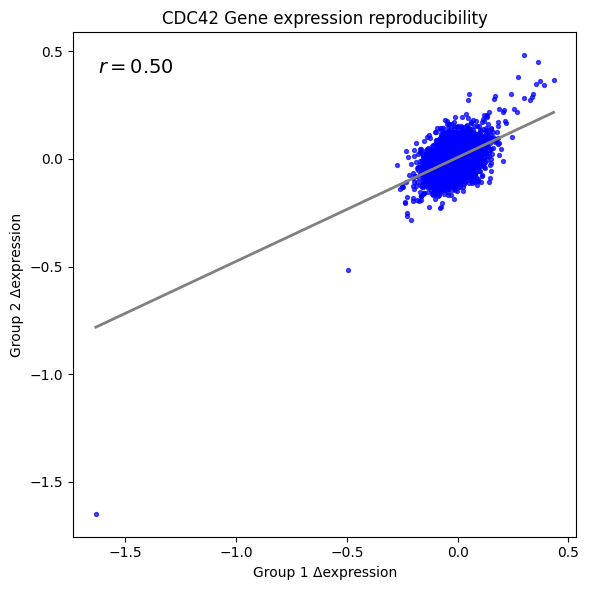

Pearson r: 0.7518815
p-value: 0.0


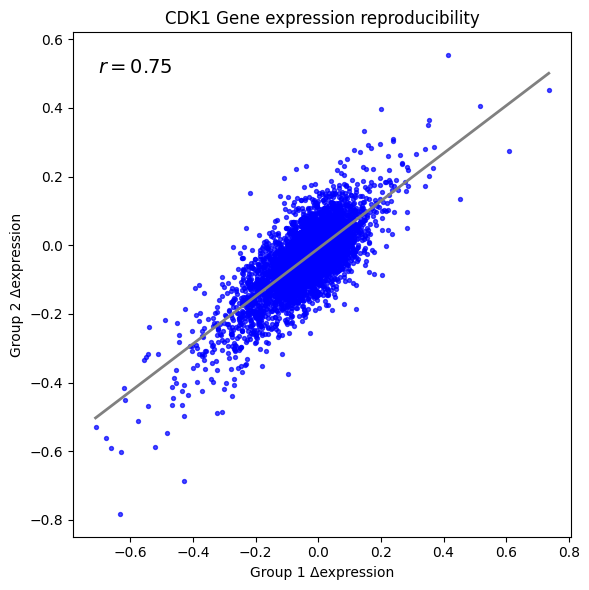

Pearson r: 0.2058341
p-value: 0.0


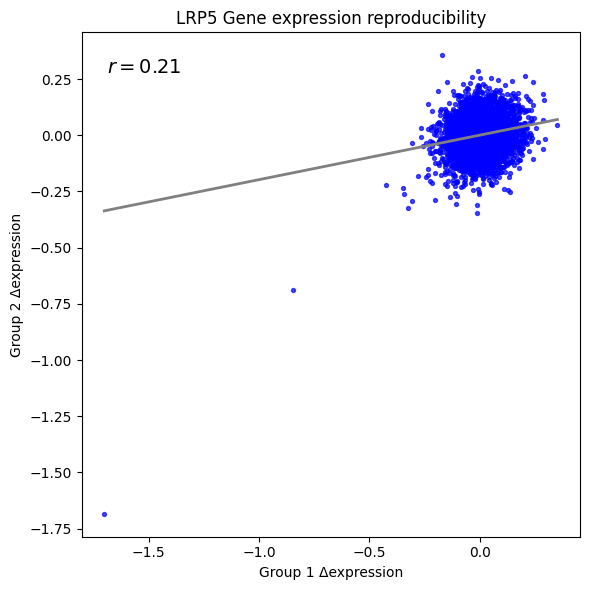

Pearson r: 0.486744
p-value: 0.0


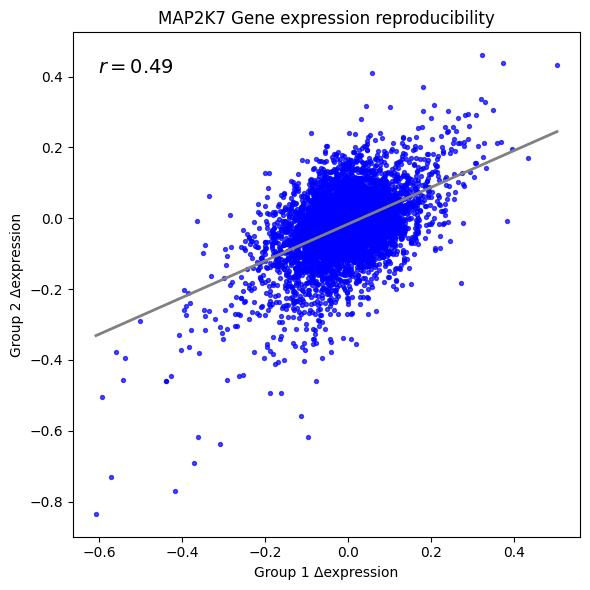

Pearson r: 0.5928675
p-value: 0.0


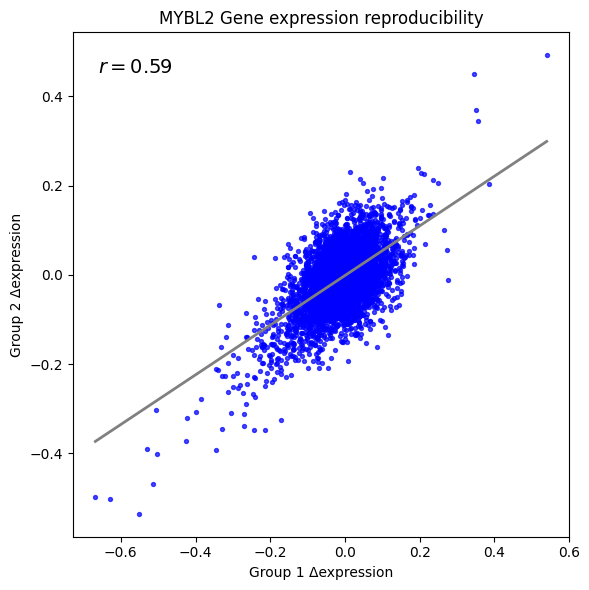

Pearson r: 0.62928486
p-value: 0.0


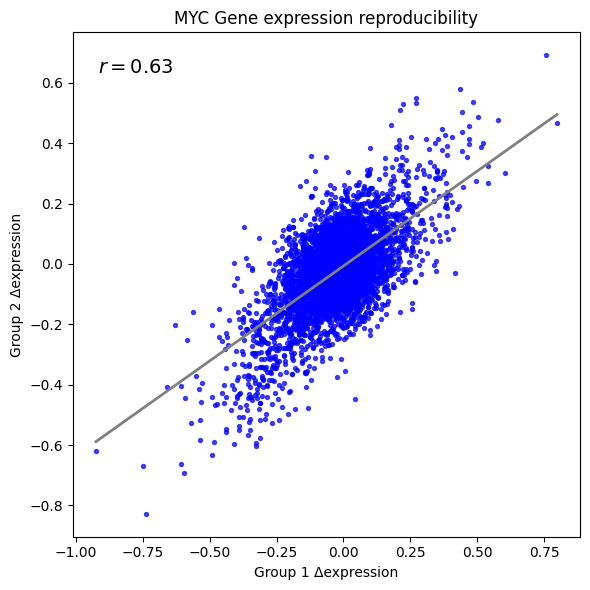

Pearson r: 0.78939754
p-value: 0.0


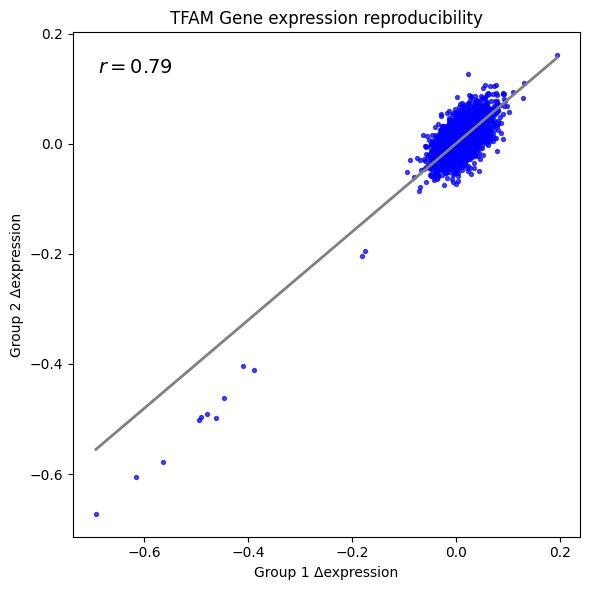

,gene,pearson r,p-val
0,CDC42,0.497836,0.0
1,CDK1,0.751881,0.0
2,LRP5,0.205834,0.0
3,MAP2K7,0.486744,0.0
4,MYBL2,0.592867,0.0
5,MYC,0.629285,0.0
6,TFAM,0.789398,0.0


In [60]:
results = []
for gene in genes_list:
    vec_g1, vec_g2, rp_dict, direction_result = calc_pearson_correlation(gene, preprocessed_sub_ds_ntc_adata)
    results.append(rp_dict)
    draw_scatter_r(vec_g1, vec_g2, gene)

res_df = pd.DataFrame(results)
res_df

In [26]:
direction_result

,gene,group1_delta,group2_delta,group1_direction,group2_direction
0,STAT5B,-0.219463,-0.196313,down,down
1,STAT5B,-0.036260,0.065530,down,up
2,STAT5B,0.200646,0.215184,up,up
3,STAT5B,0.102908,0.158016,up,up
4,STAT5B,0.014146,-0.021379,up,down
...,...,...,...,...,...
6637,STAT5B,-0.087052,0.032960,down,up
6638,STAT5B,0.078476,-0.067932,up,down
6639,STAT5B,-0.088745,-0.041236,down,down
6640,STAT5B,-0.215389,-0.070679,down,down


Pearson r: 0.48579788
p-value: 0.0


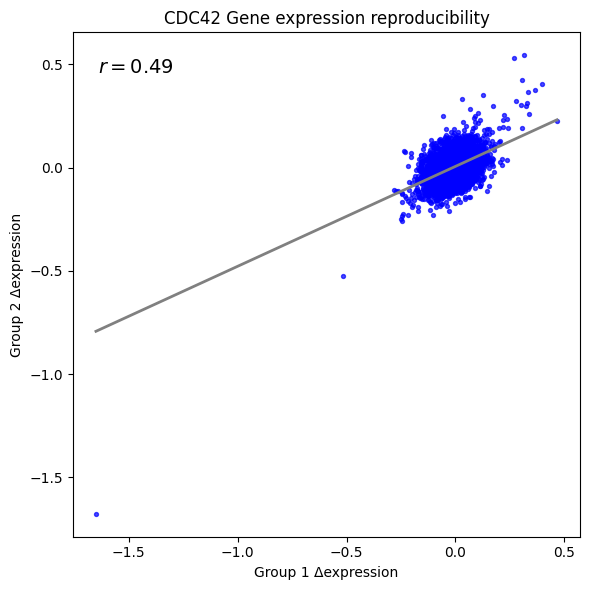

Pearson r: 0.7901202
p-value: 0.0


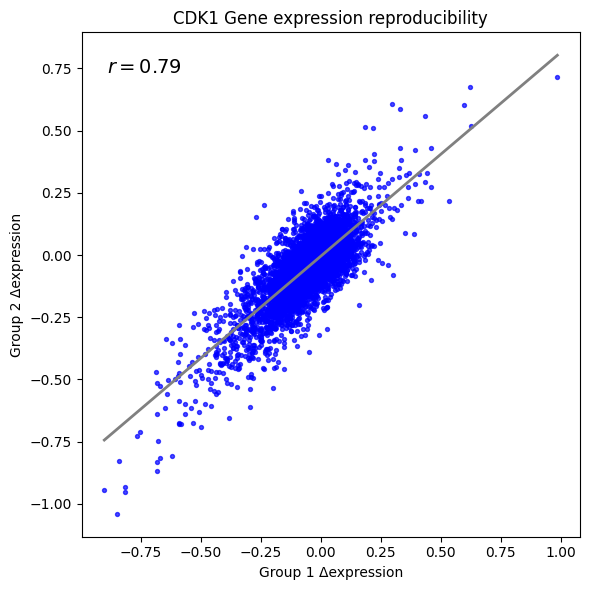

Pearson r: 0.17495443
p-value: 0.0


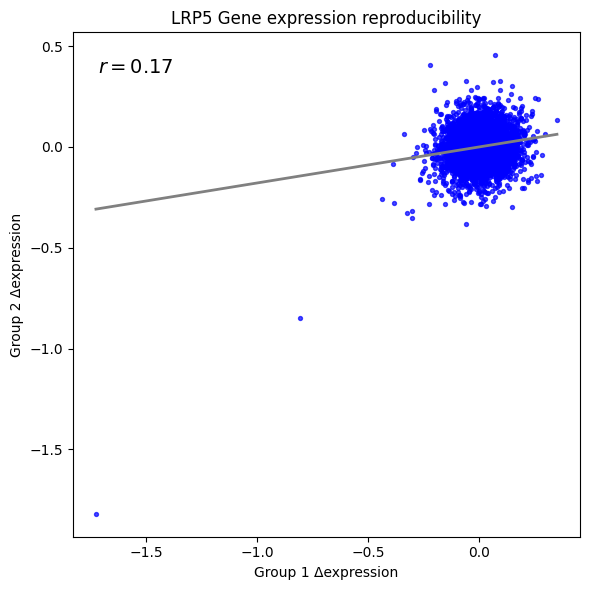

Pearson r: 0.54842687
p-value: 0.0


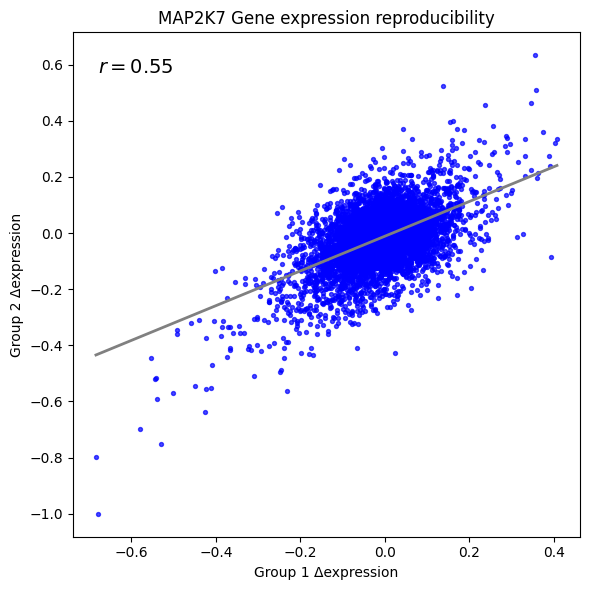

Pearson r: 0.53586435
p-value: 0.0


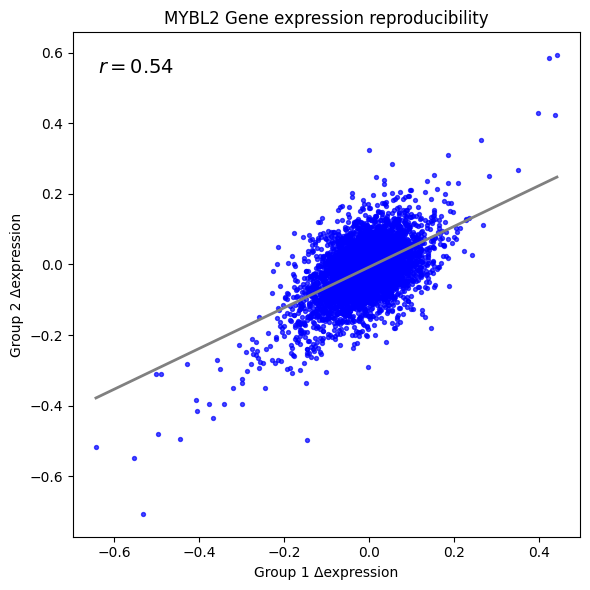

Pearson r: 0.6440026
p-value: 0.0


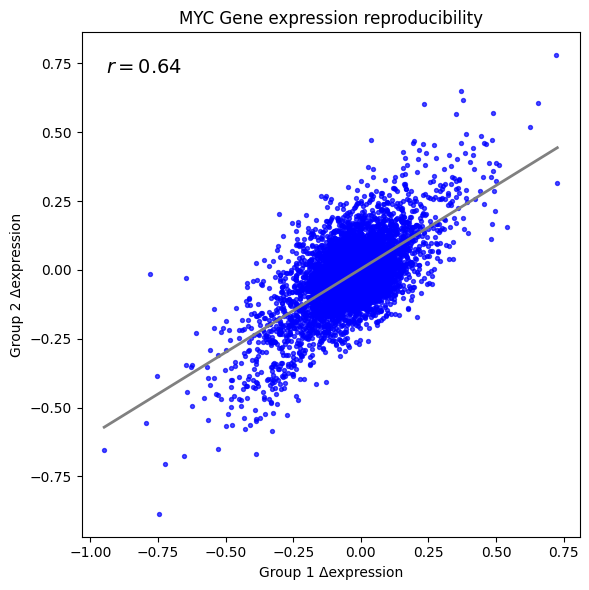

Pearson r: 0.76306754
p-value: 0.0


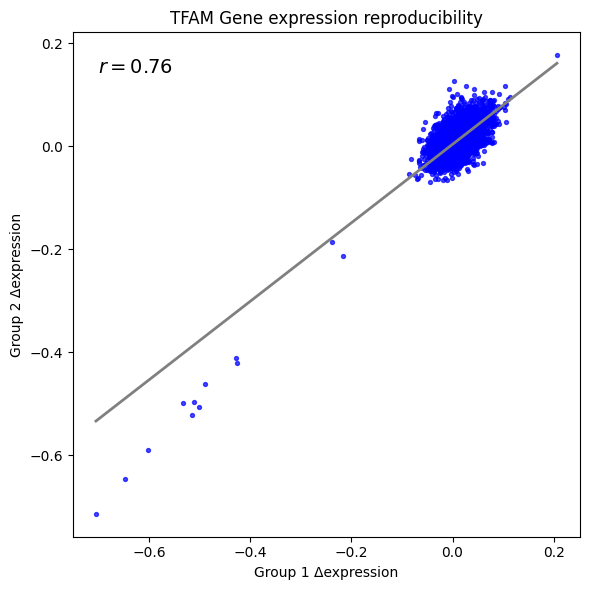

,gene,pearson r,p-val
0,CDC42,0.485798,0.0
1,CDK1,0.790120,0.0
2,LRP5,0.174954,0.0
3,MAP2K7,0.548427,0.0
4,MYBL2,0.535864,0.0
5,MYC,0.644003,0.0
6,TFAM,0.763068,0.0


In [62]:
ko_results = []
for gene in genes_list:
    vec_g1, vec_g2, rp_dict, direction_result = calc_pearson_correlation(gene, preprocessed_sub_ds_ntc_ko_ntc_adata)
    ko_results.append(rp_dict)
    draw_scatter_r(vec_g1, vec_g2, gene)

ko_res_df = pd.DataFrame(ko_results)
ko_res_df



In [53]:
res_df

,gene,pearson r,p-val
0,CDC42,0.497836,0.0
1,CDK1,0.751881,0.0
2,LRP5,0.205834,0.0
3,MAP2K7,0.486744,0.0
4,MYBL2,0.592867,0.0
5,MYC,0.629285,0.0
6,TFAM,0.789398,0.0


In [44]:

    plt.figure(figsize=(6, 6))
    
    # Scatter plot
    plt.scatter(
        vec_g1,
        vec_g2,
        s=6,          # point size
        alpha=0.35,   # transparency
        edgecolors="none"
    )
    
    # Identity line (y = x)
    xmin = min(vec_g1.min(), vec_g2.min())
    xmax = max(vec_g1.max(), vec_g2.max())
    
    plt.plot(
        [xmin, xmax],
        [xmin, xmax],
        color="red",
        linestyle="--",
        linewidth=1.5
    )
    
    plt.xlabel("Group 1 Δexpression")
    plt.ylabel("Group 2 Δexpression")
    plt.title(f"{gene} Gene expression reproducibility\nPearson r = {r:.3f}")
    
    plt.xlim(xmin, xmax)
    plt.ylim(xmin, xmax)
    
    plt.tight_layout()
    plt.show()

In [59]:
def draw_scatter_r(vec_g1, vec_g2, gene):
    # Pearson correlation
    r, p = pearsonr(vec_g1, vec_g2)
    
    plt.figure(figsize=(6,6))
    
    # Scatter
    plt.scatter(
        vec_g1,
        vec_g2,
        s=8,
        color="blue",
        alpha=0.7
    )
    
    # Best-fit regression line
    slope, intercept = np.polyfit(vec_g1, vec_g2, 1)
    
    x = np.linspace(vec_g1.min(), vec_g1.max(), 100)
    y = slope * x + intercept
    
    plt.plot(x, y, color="grey", linewidth=2)
    
    # Display Pearson r
    plt.text(
        0.05, 0.92,
        f"$r={r:.2f}$",
        transform=plt.gca().transAxes,
        fontsize=14
    )
    
    plt.xlabel("Group 1 Δexpression")
    plt.ylabel("Group 2 Δexpression")
    plt.title(f"{gene} Gene expression reproducibility")
    
    plt.tight_layout()
    plt.show()

Pearson r: 0.94122905
p-value: 0.0


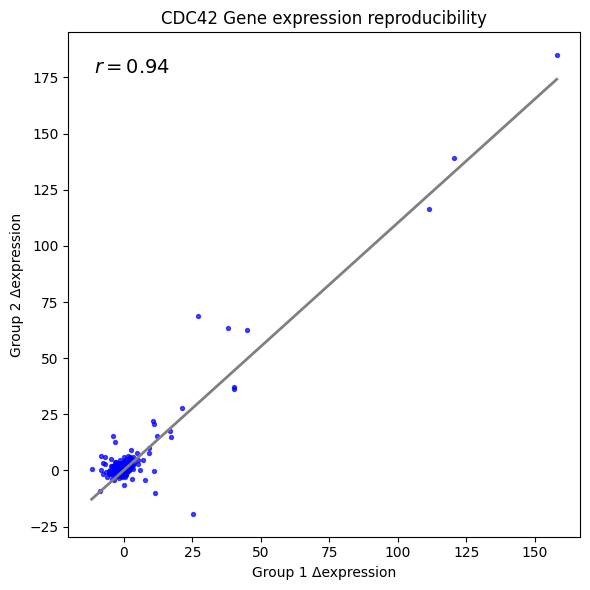

Pearson r: 0.8889782
p-value: 0.0


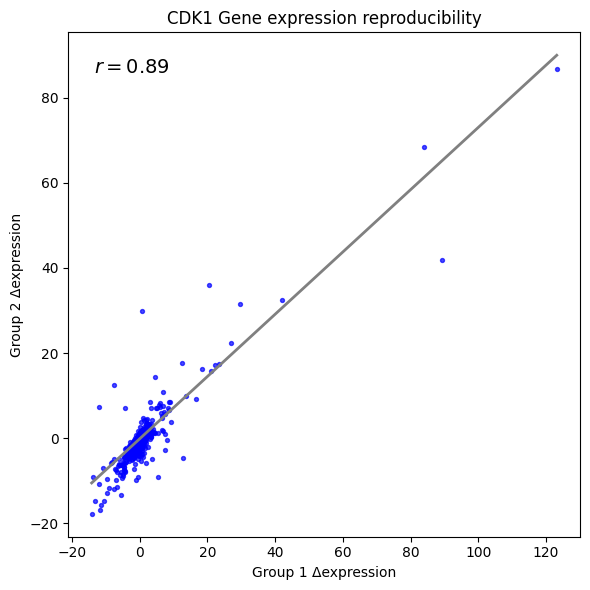

Pearson r: 0.38772392
p-value: 0.0


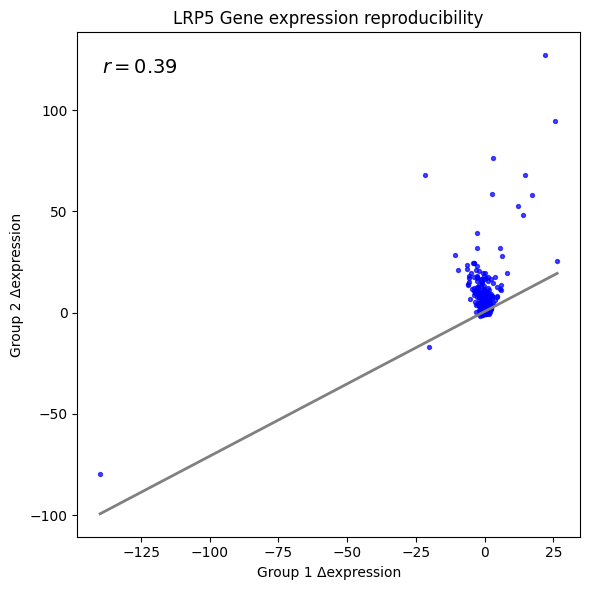

Pearson r: 0.8873011
p-value: 0.0


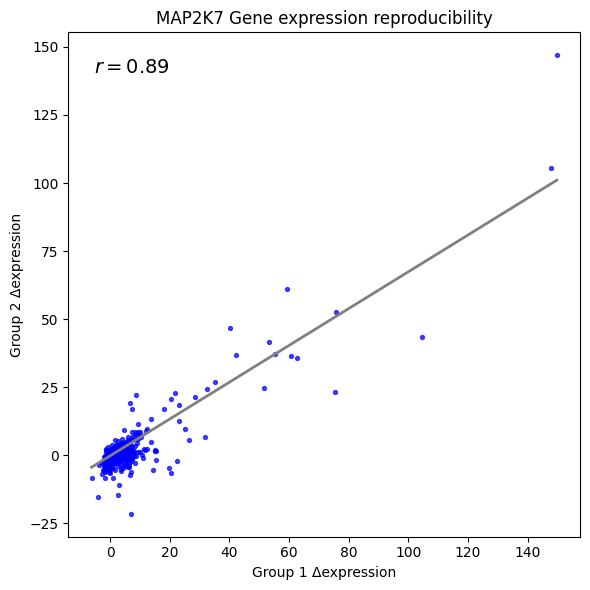

Pearson r: 0.61661536
p-value: 0.0


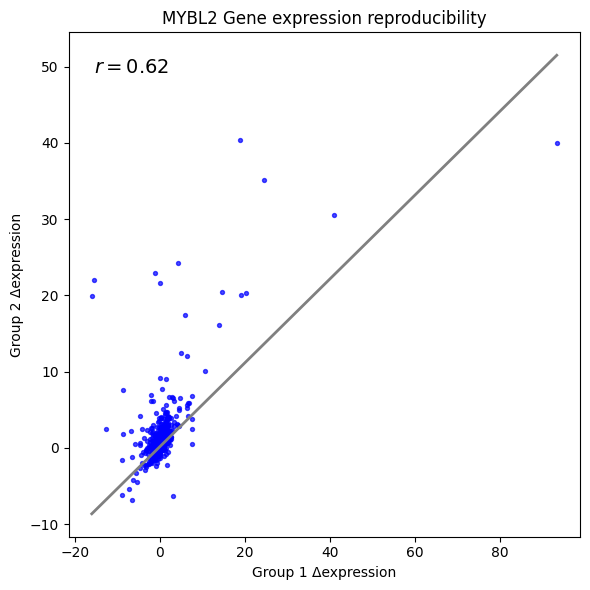

Pearson r: 0.9600669
p-value: 0.0


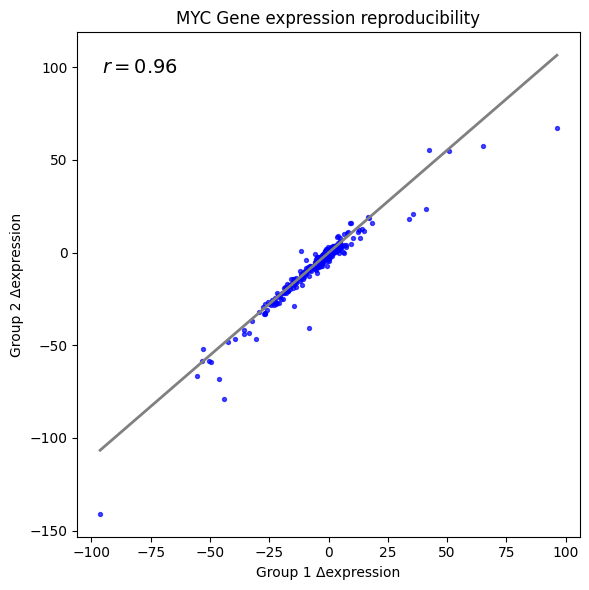

Pearson r: 0.9826732
p-value: 0.0


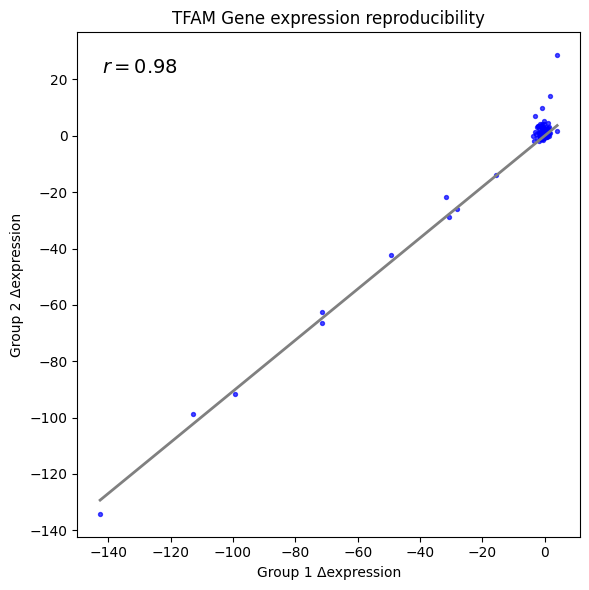

,gene,pearson r,p-val
0,CDC42,0.941229,0.0
1,CDK1,0.888978,0.0
2,LRP5,0.387724,0.0
3,MAP2K7,0.887301,0.0
4,MYBL2,0.616615,0.0
5,MYC,0.960067,0.0
6,TFAM,0.982673,0.0


In [64]:
ko_results = []
for gene in genes_list:
    vec_g1, vec_g2, rp_dict, direction_result = calc_pearson_correlation(gene, raw_sub_ds_ntc_adata)
    ko_results.append(rp_dict)
    draw_scatter_r(vec_g1, vec_g2, gene)

ko_res_df = pd.DataFrame(ko_results)
ko_res_df


In [65]:
ko_res_df

,gene,pearson r,p-val
0,CDC42,0.941229,0.0
1,CDK1,0.888978,0.0
2,LRP5,0.387724,0.0
3,MAP2K7,0.887301,0.0
4,MYBL2,0.616615,0.0
5,MYC,0.960067,0.0
6,TFAM,0.982673,0.0


Pearson r: 0.9420484
p-value: 0.0


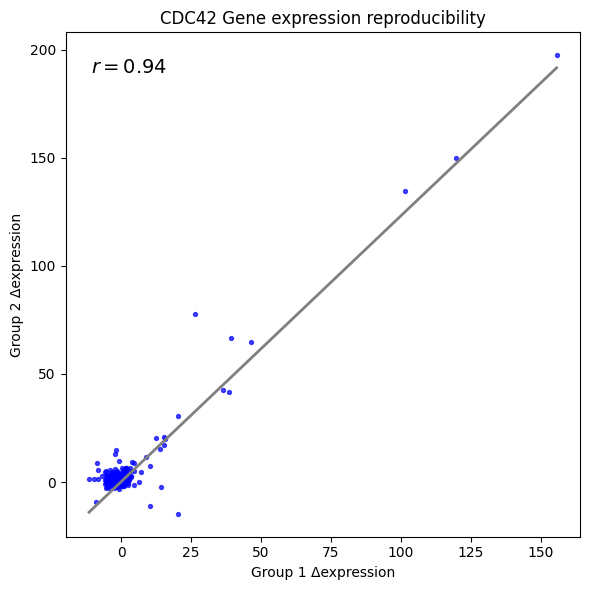

Pearson r: 0.7711379
p-value: 0.0


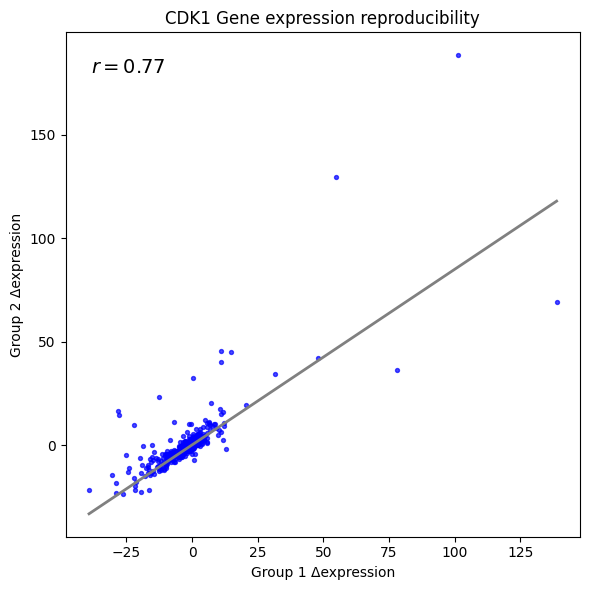

Pearson r: 0.84659374
p-value: 0.0


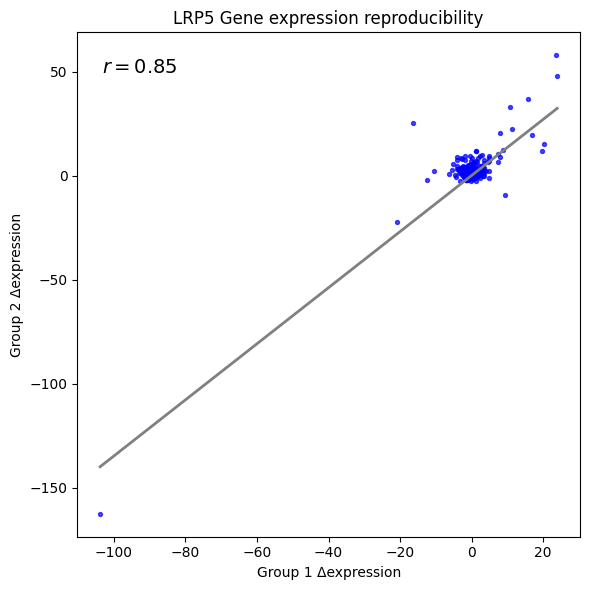

Pearson r: 0.8537725
p-value: 0.0


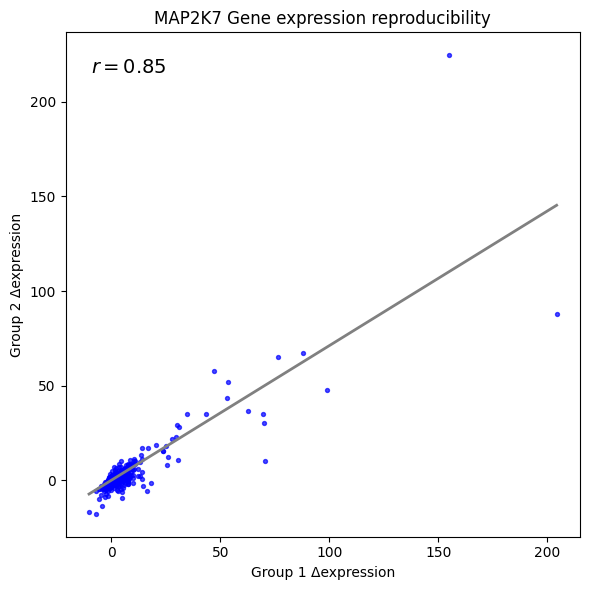

Pearson r: 0.10242982
p-value: 7.215572e-24


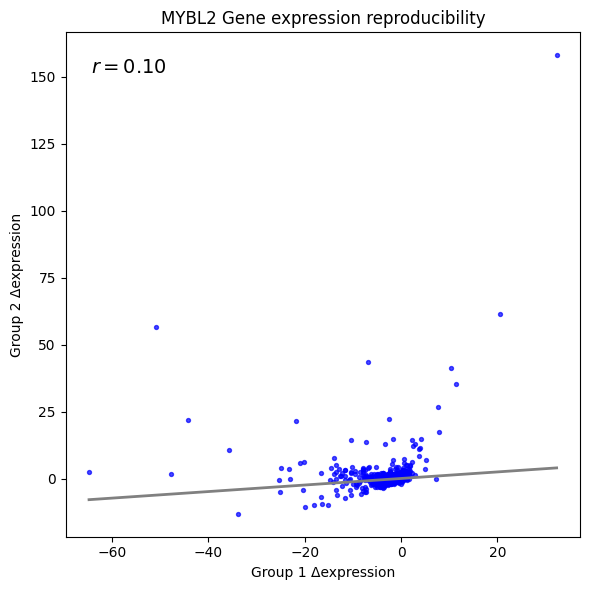

Pearson r: 0.9672507
p-value: 0.0


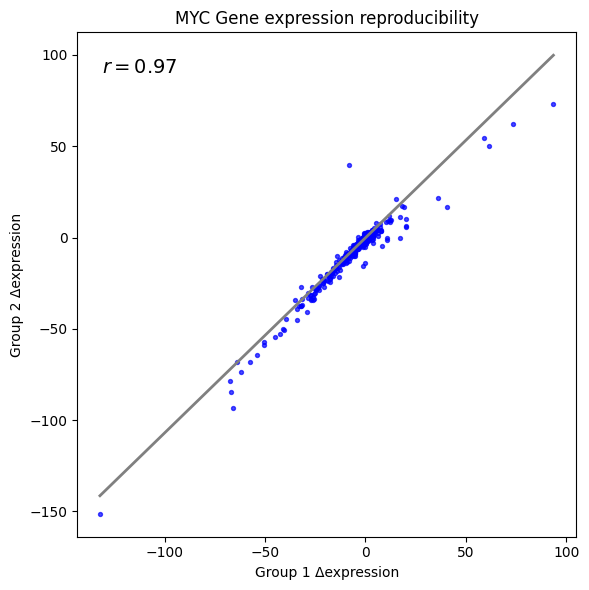

Pearson r: 0.9951553
p-value: 0.0


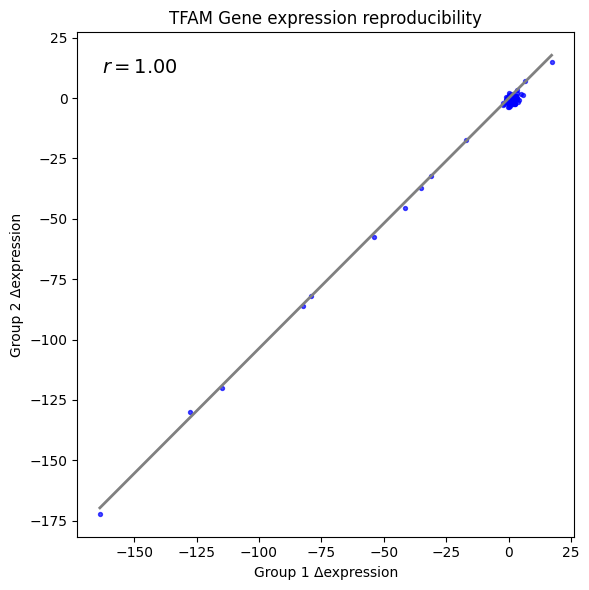

,gene,pearson r,p-val
0,CDC42,0.942048,0.000000e+00
1,CDK1,0.771138,0.000000e+00
2,LRP5,0.846594,0.000000e+00
3,MAP2K7,0.853773,0.000000e+00
4,MYBL2,0.102430,7.215572e-24
5,MYC,0.967251,0.000000e+00
6,TFAM,0.995155,0.000000e+00


In [69]:
ko_results = []
for gene in genes_list:
    vec_g1, vec_g2, rp_dict, direction_result = calc_pearson_correlation(gene, raw_sub_ds_ntc_ko_ntc_adata)
    ko_results.append(rp_dict)
    draw_scatter_r(vec_g1, vec_g2, gene)

ko_res_df = pd.DataFrame(ko_results)
ko_res_df



In [70]:
ko_res_df

,gene,pearson r,p-val
0,CDC42,0.942048,0.000000e+00
1,CDK1,0.771138,0.000000e+00
2,LRP5,0.846594,0.000000e+00
3,MAP2K7,0.853773,0.000000e+00
4,MYBL2,0.102430,7.215572e-24
5,MYC,0.967251,0.000000e+00
6,TFAM,0.995155,0.000000e+00


In [72]:
raw_sub_ds_ntc_adata.shape

(2270, 9624)

In [74]:
2270-322

1948

In [71]:
raw_sub_ds_ntc_ko_ntc_adata.shape

(1948, 9624)

# sgRNA abundance

In [18]:
sgrna_df = pd.read_csv(x_atlas_sgrna_path)
sgrna_df

,cell_barcode,num_features,feature_call,num_umis,gene_target,pass_guide_filter
0,AAACCAAAGACATGTT-HCT116_Batch1,2,ST14_P1P2-1|ST14_P1P2-2,1794|1481,ST14,True
1,AAACCAAAGACCCAAC-HCT116_Batch1,2,SIGLEC5_P1P2-1|SIGLEC5_P1P2-2,1429|962,SIGLEC5,True
2,AAACCAAAGAGGTACG-HCT116_Batch1,2,VSNL1_P1P2-1|VSNL1_P1P2-2,1284|2990,VSNL1,True
3,AAACCAAAGCGATTAT-HCT116_Batch1,2,KCNK7_P1P2-1|KCNK7_P1P2-2,1626|1382,KCNK7,True
4,AAACCAAAGGCTTAAT-HCT116_Batch1,2,APOA4_P1P2-1|APOA4_P1P2-2,5347|2860,APOA4,True
...,...,...,...,...,...,...
3409164,GTTGTGCAGGGAATCG-HCT116_Batch109,2,ACP6_P1P2-1|ACP6_P1P2-2,130|705,ACP6,True
3409165,GTTGTGGGTCACGCGG-HCT116_Batch109,2,RNF39_P1P2-1|RNF39_P1P2-2,86|58,RNF39,True
3409166,GTTGTGGGTCTGACTC-HCT116_Batch109,2,AFP_P2-1|AFP_P2-2,22|41,AFP,True
3409167,GTTGTGGGTCTTGATT-HCT116_Batch109,2,METTL9_P1P2-1|METTL9_P1P2-2,558|356,METTL9,True
